# Support Vector Machine

This notebook trains and evaluates a support vector machine classifier for predicting whether a mushroom is poisonous or edible

## Set Up

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split    
from sklearn.svm import SVC

pd.set_option('display.max_columns', None)


## Preprocessing

In [5]:
df = pd.read_csv('../Data/raw_data.csv', sep=';')

columns_to_drop = ['stem-root','veil-type', 'veil-color',  'stem-surface', 'spore-print-color']
df = df.drop(columns=columns_to_drop)
df.columns

Index(['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-color', 'has-ring', 'ring-type',
       'habitat', 'season'],
      dtype='object')

In [6]:
columns_to_drop = ['stem-root','veil-type', 'veil-color',  'stem-surface', 'spore-print-color']
df_drop_missing = df.drop(columns=columns_to_drop)
df_drop_missing.columns

KeyError: "['stem-root', 'veil-type', 'veil-color', 'stem-surface', 'spore-print-color'] not found in axis"

In [7]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline


class KNNCategoricalImputer(BaseEstimator, TransformerMixin):
    """
    Supervised KNN imputer for one or more categorical columns.

    - Assumes input X is a pandas DataFrame with original columns.
    - For each target column:
        * uses all other columns that have no missing values as predictors
        * does its own StandardScaler + OneHotEncoder internally
    """

    def __init__(self, target_cols, num_cols=None, n_neighbors=5, weights="distance"):
        # allow a single string or a list
        if isinstance(target_cols, str):
            target_cols = [target_cols]

        self.target_cols = target_cols
        self.num_cols = num_cols   # list of numeric columns to scale 
        self.n_neighbors = n_neighbors
        self.weights = weights

    def fit(self, X, y=None):
        df = X.copy()

        self.knn_models_ = {}
        self.feature_cols_ = {}

        for col in self.target_cols:
            # rows where the target is known
            mask = df[col].notna()

            # trainable columns: all except the target, and with no missing values on these rows
            _X_train_tmp = df.loc[mask].drop(columns=[col])
            train_columns = _X_train_tmp.columns[
                _X_train_tmp.isnull().sum() == 0
            ].tolist()

            X_train = df.loc[mask, train_columns]
            y_train = df.loc[mask, col]

            # numeric + categorical columns for THIS target
            if self.num_cols is None:
                # if not provided, infer numeric from dtypes
                num_cols = X_train.select_dtypes(include="number").columns.tolist()
            else:
                # keep only those num_cols that are actually in train_columns
                num_cols = [c for c in self.num_cols if c in train_columns]

            cat_cols = [c for c in train_columns if c not in num_cols + [col]]

            # preprocessor for KNN
            pre = ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), num_cols),
                    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
                ]
            )

            # KNN classifier pipeline
            clf = Pipeline(
                steps=[
                    ("pre", pre),
                    (
                        "knn",
                        KNeighborsClassifier(
                            n_neighbors=self.n_neighbors, weights=self.weights
                        ),
                    ),
                ]
            )

            # fit KNN for this target column
            clf.fit(X_train, y_train)

            # store model and the columns it expects
            self.knn_models_[col] = clf
            self.feature_cols_[col] = train_columns

        return self

    def transform(self, X):
        df = X.copy()

        for col in self.target_cols:
            mask_missing = df[col].isna()

            if mask_missing.any():
                feats = self.feature_cols_[col]
                X_missing = df.loc[mask_missing, feats]
                df.loc[mask_missing, col] = self.knn_models_[col].predict(X_missing)

        return df


In [11]:
from sklearn import set_config
from sklearn.preprocessing import LabelEncoder
set_config(transform_output="pandas") 


X = df.drop(columns='class')
y = df['class']

# label encode y 

le = LabelEncoder()
y = le.fit_transform(y)

numeric_features = X.select_dtypes(include='float64').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

# Columns to impute
features_to_impute = ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']

numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False  # 
)


knn_imputer = KNNCategoricalImputer(
    target_cols=features_to_impute,
    num_cols=numeric_features
)


column_trans = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)


preprocess = Pipeline(steps=[
    ('knn_imputer', knn_imputer),      # impute missing values using KNN 
    ('column_transformer', column_trans)  
])




X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


preprocess.fit(X_train)

X_train = preprocess.transform(X_train)
X_test = preprocess.transform(X_test)

X_train


,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_b,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_f,does-bruise-or-bleed_t,gill-attachment_a,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_c,gill-spacing_d,gill-spacing_f,gill-color_b,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_b,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,has-ring_f,has-ring_t,ring-type_e,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_z,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w
36219,-0.195867,-0.104756,-0.639647,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54188,0.039043,-0.801696,-0.439222,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1609,0.313735,1.253535,0.218893,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20481,-0.616430,-0.736450,-0.574833,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
20546,-0.654319,-0.819490,-0.613722,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28217,0.012521,-0.629685,0.036415,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
51211,-0.455404,0.013872,-0.044353,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [12]:
y_train

array([0, 1, 1, ..., 1, 1, 0])

## Exploratory Data Analysis

Load Clean Data

In [21]:
raw_data = pd.read_csv('../Data/clean_data.csv')
raw_data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,1.619462,x,g,o,f,e,c,w,3.076705,0.492293,w,t,g,d,w
1,p,1.873982,x,g,o,f,e,c,w,3.385311,0.601900,w,t,g,d,u
2,p,1.393432,x,g,o,f,e,c,w,3.328931,0.557061,w,t,g,d,w
3,p,1.412426,f,h,e,f,e,c,w,2.726555,0.381690,w,t,p,d,w
4,p,1.501699,x,h,o,f,e,c,w,2.952075,0.503254,w,t,p,d,w
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,p,-1.054903,s,s,y,f,f,f,f,-0.786809,-0.590822,y,f,f,d,a
61065,p,-1.037808,f,s,y,f,f,f,f,-1.009362,-0.669539,y,f,f,d,a
61066,p,-1.037808,s,s,y,f,f,f,f,-0.807581,-0.575875,y,f,f,d,u
61067,p,-1.043506,f,s,y,f,f,f,f,-0.896602,-0.668543,y,f,f,d,u


In [22]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           61069 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       61069 non-null  object 
 7   gill-spacing          61069 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-color            61069 non-null  object 
 12  has-ring              61069 non-null  object 
 13  ring-type             61069 non-null  object 
 14  habitat               61069 non-null  object 
 15  season             

In [23]:
raw_data.describe()

,cap-diameter,stem-height,stem-width
count,6.106900e+04,6.106900e+04,6.106900e+04
mean,6.701806e-17,2.233935e-16,-1.265897e-16
std,1.000008e+00,1.000008e+00,1.000008e+00
min,-1.206855e+00,-1.952985e+00,-1.210598e+00
25%,-6.180393e-01,-5.761259e-01,-6.914605e-01
50%,-1.659805e-01,-1.874007e-01,-1.952406e-01
75%,3.430605e-01,3.437583e-01,4.404789e-01
max,1.056187e+01,8.112329e+00,9.143259e+00


The data was standardized in the DataCleaning notebook.

In [24]:
#Check for class imbalance
raw_data['class'].value_counts()

class
p    33888
e    27181
Name: count, dtype: int64

array([[<Axes: title={'center': 'cap-diameter'}>,
        <Axes: title={'center': 'stem-height'}>],
       [<Axes: title={'center': 'stem-width'}>, <Axes: >]], dtype=object)

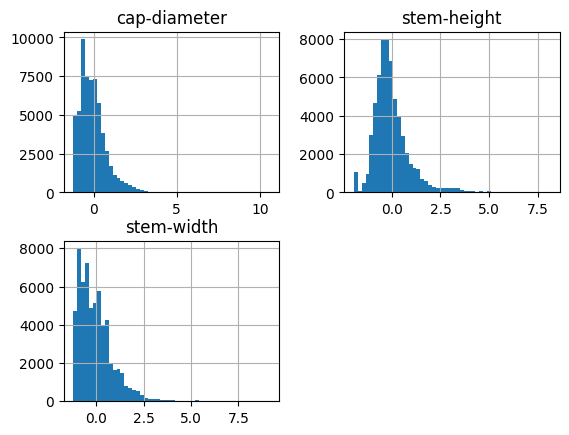

In [25]:
raw_data.hist(bins=50)

Need to transform to have a better bell shape

Now, let's create a test set. 

In [26]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(raw_data, test_size=0.2, random_state=42)

Check for correlation of numeric variables

In [27]:
# chi-square test to check independence between categorical variables
import scipy.stats as stats
from scipy.stats import chi2_contingency

# contingency table 
table = pd.crosstab(raw_data['class'], raw_data['cap-color'])

chi2, p, dof, ex = chi2_contingency(table)
print(f"{p:.10e}") # p-value
# If p-value < 0.05, we reject the null hypothesis and conclude that there is a significant association between the variables.
chi2


0.0000000000e+00


3541.079818275377

In [28]:
table

cap-color,b,e,g,k,l,n,o,p,r,u,w,y
class,,,,,,,,,,,,
e,974,880,2297,501,452,12407,1071,449,198,611,3750,3591
p,256,3155,2123,778,376,11811,2585,1254,1584,1098,3916,4952


In [29]:
from scipy.stats import chi2_contingency


# function to perform chi-square test
def test_independence(data, var1, var2):
    table = pd.crosstab(data[var1], data[var2])
    chi2, p, dof, ex = chi2_contingency(table)
    print(f"{table}")
    return p

In [30]:
# test independece between 'class' and other categorical variables
categorical_vars = raw_data.select_dtypes(include=['object']).columns.tolist()
categorical_vars.remove('class')
for var in categorical_vars:
    p_value = test_independence(raw_data, 'class', var)
    print(f"P-value for independence between 'class' and '{var}': {p_value:.10e}")
    if p_value < 0.05:
        print(f"Reject null hypothesis: 'class' and '{var}' are dependent.\n")
    else:
        print(f"Fail to reject null hypothesis: 'class' and '{var}' are independent.\n")


cap-shape     b     c     f     o     p     s      x
class                                               
e          1258   774  6502   825  1567  3295  12960
p          4436  1041  6902  2635  1031  3869  13974
P-value for independence between 'class' and 'cap-shape': 0.0000000000e+00
Reject null hypothesis: 'class' and 'cap-shape' are dependent.

cap-surface     d     e     g     h     i     k     l     s     t     w     y
class                                                                        
e            2200  2226  2008  3478   385   231  1366  5744  3806  1216  4521
p            2961  1532  3907  3206  2101  2670  1374  4052  7042  1567  3476
P-value for independence between 'class' and 'cap-surface': 0.0000000000e+00
Reject null hypothesis: 'class' and 'cap-surface' are dependent.

cap-color    b     e     g    k    l      n     o     p     r     u     w  \
class                                                                       
e          974   880  2297  501  452  12

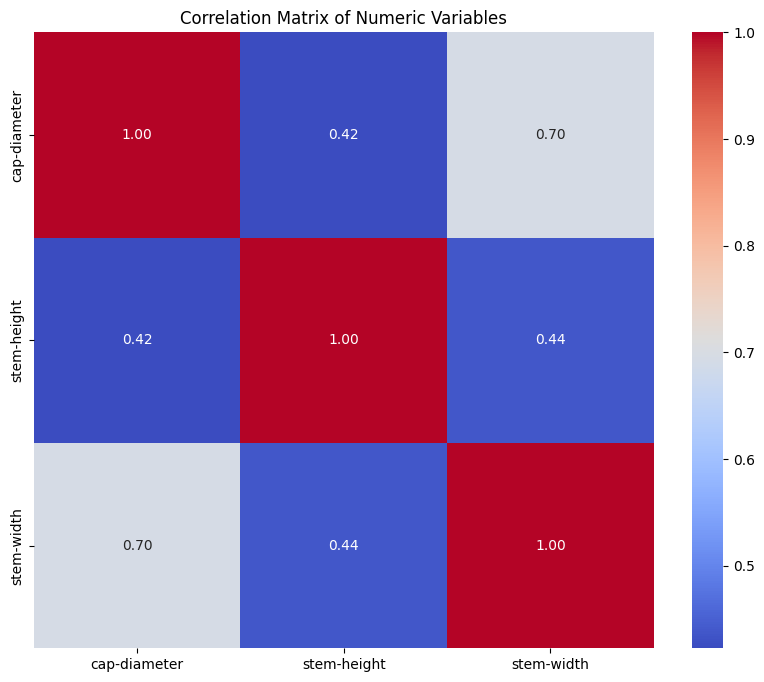

In [31]:
#Check for correlation of numeric variables
numeric_vars = raw_data.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = raw_data[numeric_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

In [32]:
# use l1 normalization on the numeric data
from sklearn.preprocessing import Normalizer
scaler = Normalizer(norm='l1')
numeric_data = raw_data.select_dtypes(include=[np.number])

# transform the numeric data
scaled_numeric_data = scaler.fit_transform(numeric_data)
scaled_numeric_df = pd.DataFrame(scaled_numeric_data, columns=numeric_data.columns)
scaled_numeric_df.describe()

# combine normalized numeric data with categorical data
categorical_data = raw_data.select_dtypes(include=['object']).reset_index(drop=True)
normalized_data = pd.concat([scaled_numeric_df, categorical_data], axis=1)
normalized_data.describe()



,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,-0.055402,-0.056587,-0.060957
std,0.333808,0.402070,0.390392
min,-0.976512,-0.987554,-0.992083
25%,-0.344921,-0.347397,-0.386375
50%,-0.150207,-0.143383,-0.199298
75%,0.238631,0.236063,0.277598
max,0.985443,0.996897,0.994495


One hot encode categorical variables


In [33]:
#=========NOTE===============

# Use column transformer for all preprocessing (after chi squared test)

# initalized cat variables 

# intialize numeric variables 

# normalize numeric variables 

# one hot encode numeric 

In [34]:
normalized_data

,cap-diameter,stem-height,stem-width,class,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-color,has-ring,ring-type,habitat,season
0,0.312128,0.592990,0.094882,p,x,g,o,f,e,c,w,w,t,g,d,w
1,0.319727,0.577581,0.102692,p,x,g,o,f,e,c,w,w,t,g,d,u
2,0.263936,0.630548,0.105515,p,x,g,o,f,e,c,w,w,t,g,d,w
3,0.312437,0.603131,0.084432,p,f,h,e,f,e,c,w,w,t,p,d,w
4,0.302943,0.595533,0.101523,p,x,h,o,f,e,c,w,w,t,p,d,w
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,-0.433664,-0.323453,-0.242883,p,s,s,y,f,f,f,f,y,f,f,d,a
61065,-0.382009,-0.371538,-0.246452,p,f,s,y,f,f,f,f,y,f,f,d,a
61066,-0.428622,-0.333537,-0.237841,p,s,s,y,f,f,f,f,y,f,f,d,u
61067,-0.400018,-0.343703,-0.256279,p,f,s,y,f,f,f,f,y,f,f,d,u


In [35]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

encoder = OneHotEncoder(sparse_output = False)

# categorical columns not including class
categorical_features = raw_data.select_dtypes(include=['object']).drop(columns=['class'])

# fit and transform the all categorical columns
encoded_features = encoder.fit_transform(raw_data[categorical_features.columns])

# encode target variable
le = LabelEncoder()
raw_data['class'] = le.fit_transform(raw_data['class'])

# combine encoded features with normalized numeric features
final_data = pd.concat([scaled_numeric_df, pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features.columns)), raw_data['class'].reset_index(drop=True)], axis=1)
final_data

,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_b,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_f,does-bruise-or-bleed_t,gill-attachment_a,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_c,gill-spacing_d,gill-spacing_f,gill-color_b,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_b,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,has-ring_f,has-ring_t,ring-type_e,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_z,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w,class
0,0.312128,0.592990,0.094882,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,0.319727,0.577581,0.102692,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
2,0.263936,0.630548,0.105515,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
3,0.312437,0.603131,0.084432,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,0.302943,0.595533,0.101523,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,-0.433664,-0.323453,-0.242883,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
61065,-0.382009,-0.371538,-0.246452,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.

In [36]:
# verify poisonous is positive class label
le.classes_[1]

'p'

Model training

In [37]:
target = 'class'

# features 
X = final_data.drop(columns=target)

# Class (poison or edible)
y = final_data[target]

In [38]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

## Linear SVM

In [13]:
# build linear svm with hinge loss
from sklearn.svm import LinearSVC
linear_svm = LinearSVC(random_state=42, loss='hinge', fit_intercept = False)

linear_svm.fit(X_train, y_train)

/Users/gerardogutierrez/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(fit_intercept=False, loss='hinge', random_state=42)

Evaluate model

In [14]:
y_pred_score = linear_svm.decision_function(X_test)
y_pred_score

array([-0.88897005,  0.89995139, -0.62771624, ...,  4.64282244,
       -1.01086325, -1.44379982])

In [15]:
y_pred_class = linear_svm.predict(X_test)
y_pred_class

array([0, 1, 0, ..., 1, 0, 0])

In [16]:
from sklearn.metrics import roc_auc_score
roc_auc_svm = roc_auc_score(y_test, y_pred_score)
print(f"SVM ROC AUC Score: {roc_auc_svm:.4f}")

SVM ROC AUC Score: 0.8438


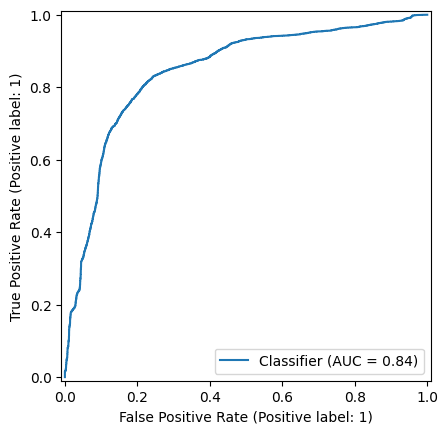

In [17]:
# plot roc curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_score)

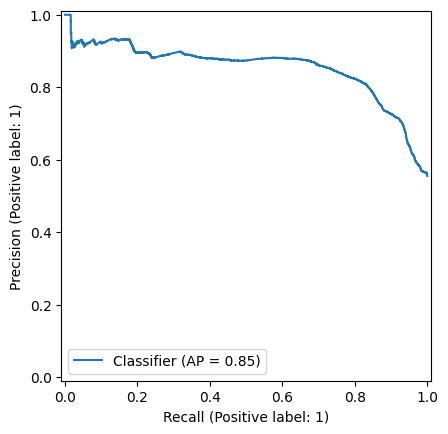

In [18]:
# plot precision vs recall
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_pred_score)

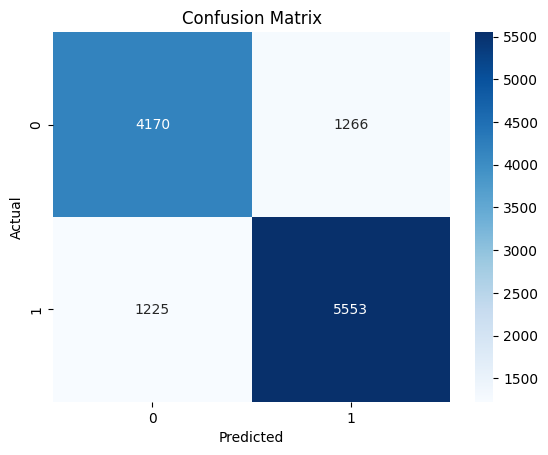

In [21]:
# get confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_class)
# cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [22]:
# get classification report and accuracy
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
report = classification_report(y_test, y_pred_class)
accuracy = accuracy_score(y_test, y_pred_class)
print(report)
print(f'Accuracy: {accuracy:.2f}')

              precision    recall  f1-score   support

           0       0.77      0.77      0.77      5436
           1       0.81      0.82      0.82      6778

    accuracy                           0.80     12214
   macro avg       0.79      0.79      0.79     12214
weighted avg       0.80      0.80      0.80     12214

Accuracy: 0.80


In [30]:
# create function to plot top 15 highest absolute value coefficients and a second plot for the bottom 15 lowest absolute value coefficients but keep scale the same fo rboth plots
def plot_feature_importance(model, feature_names, top_n=15):
    
    coefs = model.coef_[0]
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefs})
    feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
    feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False).drop(columns=['Abs_Importance'])
    
    top_features = feature_importance.head(top_n)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
    plt.xlabel('Coefficient Value')
    plt.title(f'Top {top_n} Feature Importance')
    # set limits to be the same for both plots
    x_limits = plt.xlim()
    plt.xlim(x_limits)
    plt.show()

    bottom_features = feature_importance.tail(top_n)
    plt.figure(figsize=(10, 6))
    plt.barh(bottom_features['Feature'], bottom_features['Importance'], color='salmon')
    plt.xlabel('Coefficient Value')
    plt.title(f'Bottom {top_n} Feature Importance')
     # Keep the same scale as the top features plot
    plt.xlim(x_limits)
    plt.show()

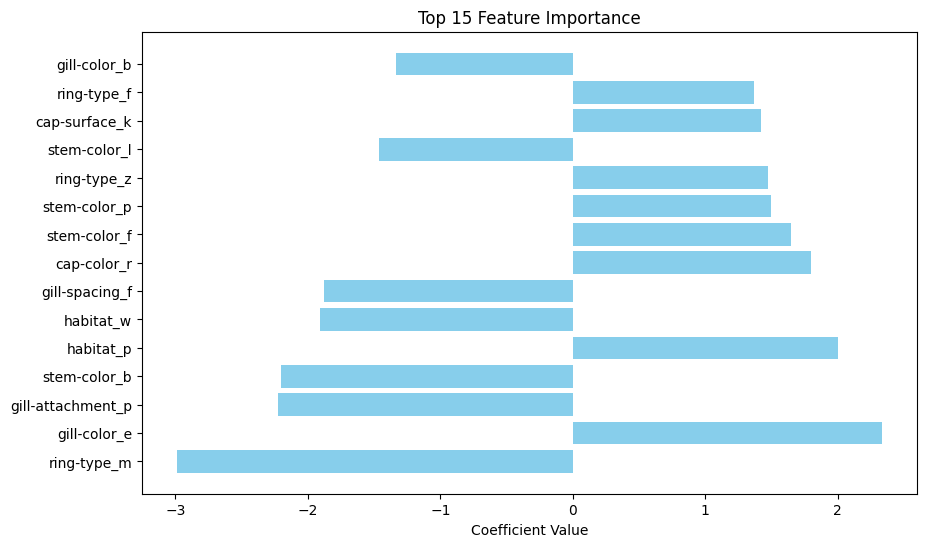

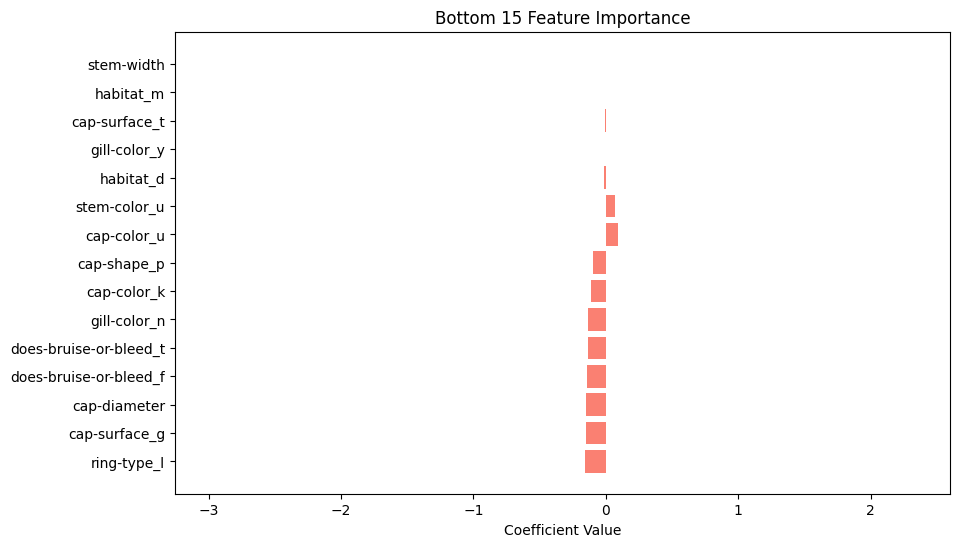

In [34]:
# plot coefficients
plot_feature_importance(linear_svm, X_train.columns, top_n=15)

## Kernel SVM

In [25]:
from sklearn.svm import SVC
clf_rbf = SVC(kernel='rbf', gamma = 'auto', C = 1.0, random_state=42)
clf_rbf.fit(X_train, y_train)

SVC(gamma='auto', random_state=42)

Evaluate Kernel SVM

In [35]:
y_pred_score_rbf = clf_rbf.decision_function(X_test)
y_pred_score_rbf

array([-1.3229621 ,  1.28272389,  0.07777406, ...,  1.29707467,
       -1.35642595, -1.3768707 ])

In [36]:
y_pred_class_rbf = clf_rbf.predict(X_test)
y_pred_class_rbf

array([0, 1, 1, ..., 1, 0, 0])

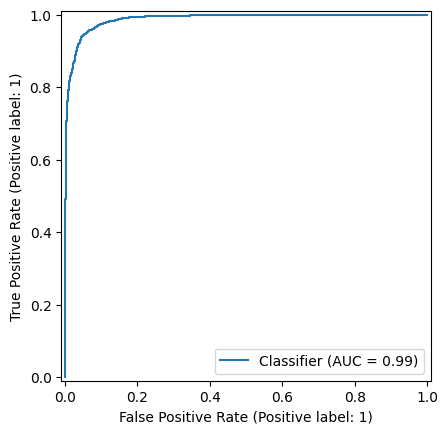

In [37]:
# plot roc curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_score_rbf)

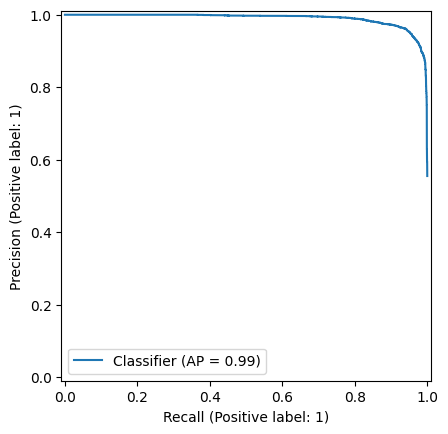

In [38]:
# plot precision vs recall
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_pred_score_rbf)

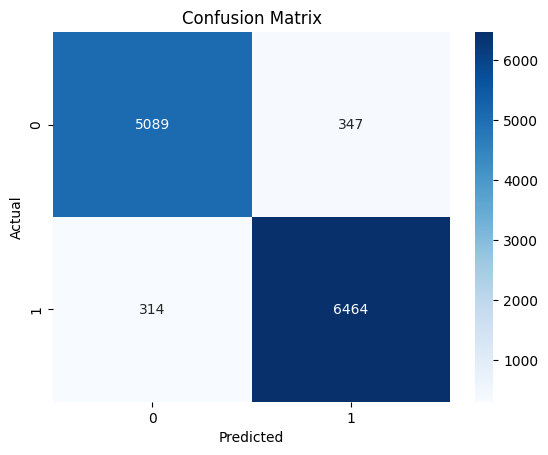

In [39]:
# get confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_class_rbf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [40]:
# classification report and accuracy
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
report = classification_report(y_test, y_pred_class_rbf)
accuracy = accuracy_score(y_test, y_pred_class_rbf)
print(report)
print(f'Accuracy: {accuracy:.2f}')

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5436
           1       0.95      0.95      0.95      6778

    accuracy                           0.95     12214
   macro avg       0.95      0.94      0.95     12214
weighted avg       0.95      0.95      0.95     12214

Accuracy: 0.95


In [ ]:
#######=========NOTE===============
# try model with only important features from linear svm
#
#
#
#
#

In [ ]:
#####========NOTE============
####
#
#
#
#
#
# Maybe do ablation analysis

## Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression
lr_clf = LogisticRegression(random_state=42, C=1.0)
lr_clf.fit(X_train, y_train)

# print iterations taken to converge
print(f"Converged in {lr_clf.n_iter_[0]} iterations.")

Converged in 79 iterations.


evaluate Logistic Regression

In [42]:
y_pred_score_lr = lr_clf.decision_function(X_test)
y_pred_score_lr

array([-0.34105194,  1.23956497, -0.7345772 , ...,  4.38472822,
       -1.52121965, -2.1069564 ])

In [43]:
y_pred_lr = lr_clf.predict(X_test)
y_pred_lr

array([0, 1, 0, ..., 1, 0, 0])

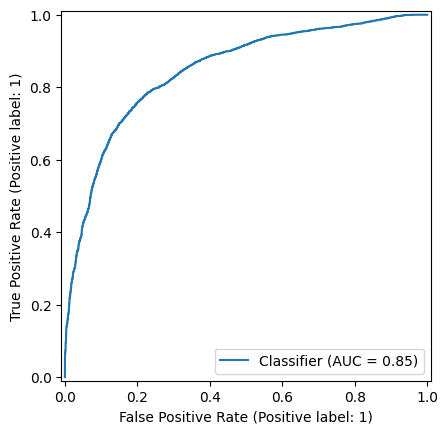

In [44]:
# plot roc curve 
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_score_lr)

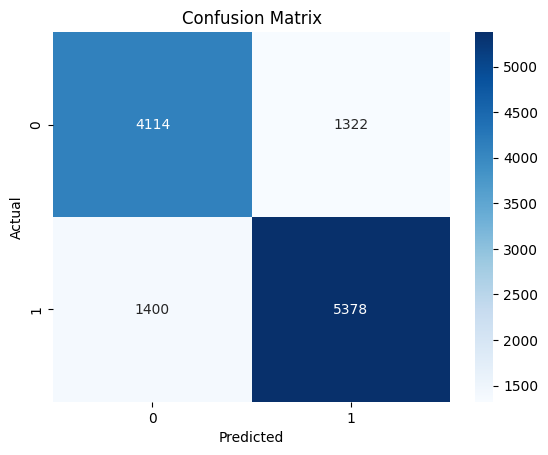

In [45]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [46]:
# get classification report and accuracy
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
report = classification_report(y_test, y_pred_lr)
accuracy = accuracy_score(y_test, y_pred_lr)
print(report)
print(f'Accuracy: {accuracy:.2f}')

              precision    recall  f1-score   support

           0       0.75      0.76      0.75      5436
           1       0.80      0.79      0.80      6778

    accuracy                           0.78     12214
   macro avg       0.77      0.78      0.77     12214
weighted avg       0.78      0.78      0.78     12214

Accuracy: 0.78


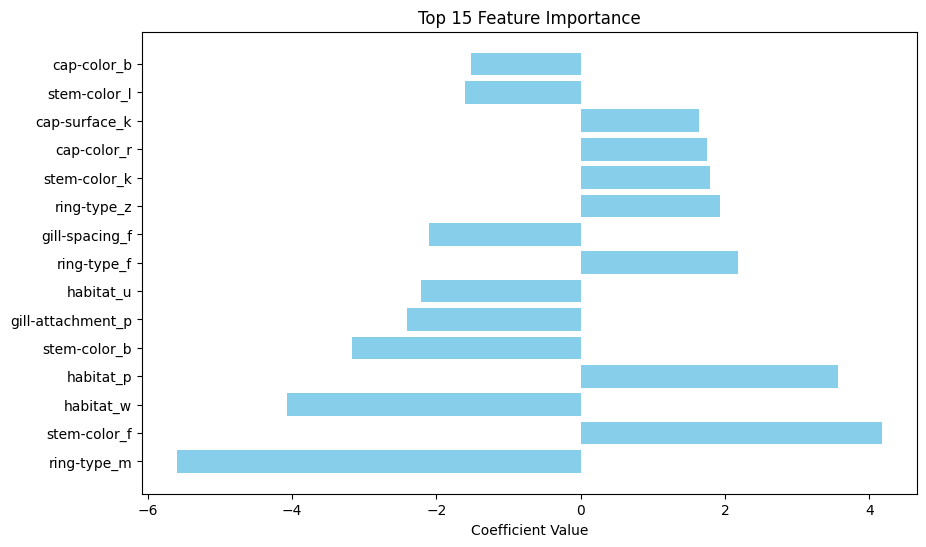

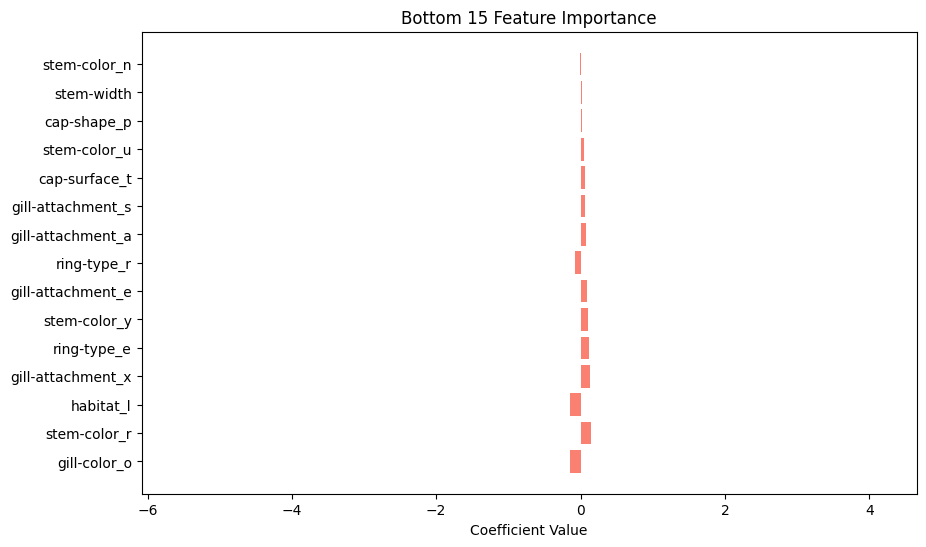

In [47]:
# plot feature importance for logistic regression
plot_feature_importance(lr_clf, X_train.columns, top_n=15)

# Knn

In [48]:
# create quick knn model and get classification report
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
knn_y_pred = knn_clf.predict(X_test)
from sklearn.metrics import classification_report
knn_report = classification_report(y_test, knn_y_pred)
print(knn_report)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5436
           1       1.00      1.00      1.00      6778

    accuracy                           1.00     12214
   macro avg       1.00      1.00      1.00     12214
weighted avg       1.00      1.00      1.00     12214



In [40]:
# roc auc for knn
from sklearn.metrics import roc_auc_score
knn_y_pred_score = knn_clf.predict_proba(X_test)[:, 1]
knn_roc_auc = roc_auc_score(y_test, knn_y_pred_score)
print(f"KNN ROC AUC Score: {knn_roc_auc:.4f}") 


KNN ROC AUC Score: 0.9998


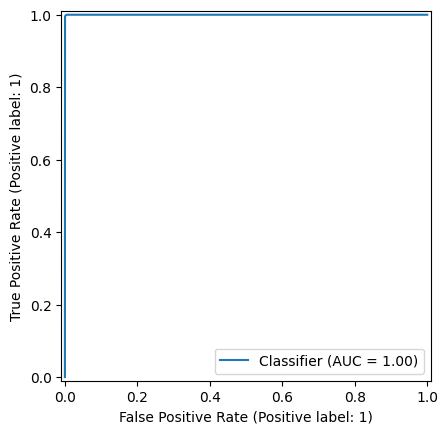

In [41]:
# plot roc curve for knn
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, knn_y_pred_score)